## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns

import time 
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights, convnext_base, ConvNeXt_Base_Weights
from torcheval.metrics import BinaryAUROC, BinaryAUPRC, BinaryAccuracy
from torch.nn.functional import softmax

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.models import MyModel
from deepfake_utils.train import validate_epoch

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results/frozen_experiment_results.csv")
experiment_results.head()

,experiment_id,model,freeze_layers,dropout_rate,l2-penalty,optimizer,epochs,learning_rate,lr_scheduler_type,train_loss_history,...,val_pr_auc_history,val_acc_history,train_loss,train_roc_auc,train_pr_auc,train_acc,val_loss,val_roc_auc,val_pr_auc,val_acc
0,1,ConvNeXt-base-pretrained,True,0.0,0.0,Adam,10,0.0100,StepLR,"[0.6327437068953182, 0.48405920839135025, 0.40...",...,"[0.8674655556678772, 0.8764898777008057, 0.864...","[0.7191780805587769, 0.732876718044281, 0.7636...",0.357527,0.919057,0.948387,0.854945,0.553438,0.811256,0.871820,0.763699
1,2,ConvNeXt-base-pretrained,True,0.0,0.0,Adam,10,0.0100,CosineAnnealingWarmRestarts,"[0.6270229053147983, 0.4646266539018233, 0.434...",...,"[0.84920734167099, 0.8687542676925659, 0.86127...","[0.7123287916183472, 0.7363013625144958, 0.722...",0.357694,0.916510,0.944180,0.836630,0.552915,0.823034,0.880403,0.777397
2,3,ConvNeXt-base-pretrained,True,0.0,0.0,Adam,10,0.0010,StepLR,"[0.6190035488142636, 0.5332471505189553, 0.502...",...,"[0.8083906769752502, 0.8279300928115845, 0.839...","[0.7226027250289917, 0.7294520735740662, 0.739...",0.459673,0.869596,0.915496,0.789011,0.520368,0.805687,0.859684,0.750000
3,4,ConvNeXt-base-pretrained,True,0.0,0.0,Adam,10,0.0010,CosineAnnealingWarmRestarts,"[0.628810176220569, 0.5398167054731767, 0.5099...",...,"[0.7958645820617676, 0.8353408575057983, 0.851...","[0.698630154132843, 0.7226027250289917, 0.7328...",0.432168,0.886005,0.924123,0.802198,0.510112,0.814755,0.875996,0.756849
4,5,ConvNeXt-base-pretrained,True,0.0,0.0,Adam,10,0.0001,StepLR,"[0.6724388667515346, 0.6454199759514777, 0.635...",...,"[0.6499453783035278, 0.6810658574104309, 0.694...","[0.585616409778595, 0.6301369667053223, 0.6506...",0.613339,0.711162,0.782872,0.695971,0.633885,0.672876,0.727950,0.671233


In [4]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").first()[['experiment_id', 'val_roc_auc', 'val_pr_auc', 'val_acc', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss']]
# experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").head(3)

,experiment_id,val_roc_auc,val_pr_auc,val_acc,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss
model,,,,,,,,,
ConvNeXt-base-pretrained,7,0.833629,0.889282,0.777397,0.512759,0.911578,0.944492,0.832967,0.369317
ResNet-50-pretrained,81,0.840183,0.893536,0.780822,0.501716,0.881087,0.921771,0.793407,0.466415
ViT-b32-pretrained,50,0.790804,0.862061,0.722603,0.590629,0.927421,0.954922,0.853480,0.335836


# Bias vs. Variance (Overfitting etc.)

In [5]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_loss_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_loss_history'])

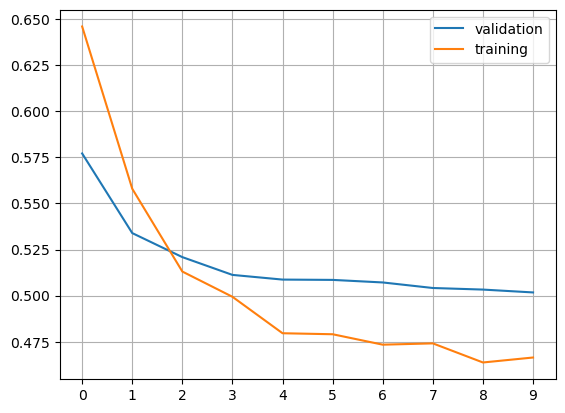

In [6]:
# if we end up showing learning curves in final report, maybe show 3 sets of train vs. val learning curves, 1 for each of the best 3 models
# see if it looks too crowded in 1 plot, or need to separate into 3 subplots side-by-side
 
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

In [7]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_roc_auc_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_roc_auc_history'])

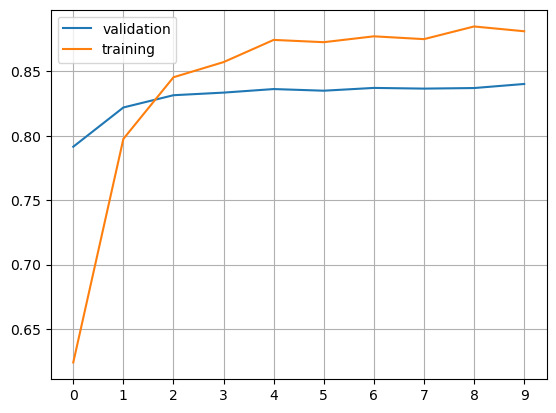

In [8]:
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

## Evaluate Test Performance (ROC curves, precision-recall curves, tables etc.)

In [9]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

In [10]:
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type = 'ResNet', is_train = False)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = 'ResNet',  is_train = False)
test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)
print(f"Successfully loaded {len(test_data)} samples for testing.")
print(f"Test data will be loaded in batches of {test_data_loader.batch_size}.")

Successfully loaded 293 samples for testing.
Test data will be loaded in batches of 32.


In [11]:
# maybe copy code from validate_epoch or create new utility function that returns the actual per-sample predictions so that we can plot ROC curves etc.
# this particular commit probably has tensors needed to do that
# https://github.com/Deepfake-Detection-KKO/deepfake-detection/blob/59df359e6d76043bd40df4a3fa0571ce67f79861/deepfake_utils/train.py

In [12]:
# Custom validate_epoch function to accumulate adn return all labels and probabilites for ROC-AUC and PR-AUC plots. 
def print_(message, log = True):
    if log:
        print(message)

def validate_epoch(dataloader, model, loss_fn, device, verbose = True, log_interval=5, return_preds_labels=False):
    model.eval() 
    val_loss = 0
    acc_metric = BinaryAccuracy(device=device)
    auroc_metric = BinaryAUROC(device=device)
    auprc_metric = BinaryAUPRC(device=device)

    all_labels = []
    all_probabilities = []
    
    loss_fn.reduction = 'sum' 
    
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            
            pred_prob = softmax(pred, dim = 1)
            
            if return_preds_labels:
                all_labels.extend(y.cpu().numpy())
                all_probabilities.extend(pred_prob[:, 1].cpu().numpy())

            acc_metric.update(pred_prob[:, 1], y)
            auroc_metric.update(pred_prob[:, 1], y)
            auprc_metric.update(pred_prob[:, 1], y)
        
            if (batch + 1) % log_interval == 0 or (batch + 1) == len(dataloader):
                current = (batch + 1) * dataloader.batch_size
                print_(f"\tEvaluation Progress: \t[{current:>5d}/{len(dataloader.dataset):>5d}]", verbose)

    val_loss /= len(dataloader.dataset)
    val_acc = acc_metric.compute()
    
    if device.type == 'mps':
        results = (val_loss, float('nan'), float('nan'), val_acc.item())
    else:
        val_auroc = auroc_metric.compute()
        val_auprc = auprc_metric.compute()
        results = (val_loss, val_auroc.item(), val_auprc.item(), val_acc.item())

    if return_preds_labels:
        return (*results, np.array(all_probabilities), np.array(all_labels))
    else:
        return results

In [14]:
# Dictionary to store results for plotting 
model_results = {} 

# Adjust these paths to your actual saved model weights. Currentlt, it is hardcoded
models_to_test = {
    "ConvNeXt-base-pretrained": 'model_weights/experiment_1.pth',
    "ResNet-50-pretrained": 'model_weights/experiment_33.pth',
    "ViT-b32-pretrained": 'model_weights/experiment_26.pth',
}

In [ ]:
# Loop through each model to load, evaluate, and collect data for the ROC-AUC and PR-AUC plots
for model_name, weights_path in models_to_test.items():
    print(f"\n Evaluating {model_name}")

    # Initialize the model architecture
    current_model = MyModel(model_name, device, num_classes=2, freeze_layers=True)
    # Load the specific model's weights
    try:
        current_model_weights = torch.load(weights_path, weights_only=True, map_location=device)
        current_model_weights_cleaned = type(current_model_weights)([
            (k.replace("_orig_mod.", ""), v) for k, v in current_model_weights.items()
        ])
        current_model.load_state_dict(current_model_weights_cleaned)
        print(f"Loaded weights for {model_name} from {weights_path}.")
    except FileNotFoundError:
        print(f"Error: {weights_path} not found. Skipping {model_name}.")
        continue
    except Exception as e:
        print(f"Error loading state_dict for {model_name} from {weights_path}: {e}. Skipping.")
        continue

    current_model.to(device) 
    # Get predictions and labels from the test set using validate_epoch
    # Pass return_preds_labels=True to get per-sample data
    # The return type depends on whether device.type == 'mps'
    results = validate_epoch(
        dataloader=test_data_loader, 
        model=current_model,
        loss_fn=nn.CrossEntropyLoss(), 
        device=device,
        verbose=True,
        return_preds_labels=True # Crucial for getting data for ROC curve
    )

    # Unpack results based on the return_preds_labels flag and MPS check
    if device.type == 'mps':
        test_loss, _, _, test_accuracy, all_probs, all_labels = results
        test_roc_auc_for_display = float('nan') # Explicitly set NaN for print
    else:
        test_loss, test_roc_auc_for_display, test_pr_auc_for_display, test_accuracy, all_probs, all_labels = results

    print(f"\n--- {model_name} Test Results ---")
    print(f"Test Loss: {test_loss:.4f}")
    # Handle printing ROC AUC/PR AUC based on MPS
    if device.type == 'mps':
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f} (Not computed on MPS)")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f} (Not computed on MPS)")
    else:
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f}")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Calculate ROC curve from collected probabilities and labels
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    calculated_roc_auc = auc(fpr, tpr)
    
    # Calculate Precision-Recall curve
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    calculated_pr_auc = auc(recall, precision) 
    FIGURE_WIDTH = 6.875 
    FIGURE_HEIGHT = FIGURE_WIDTH * 0.75 
    FONTSIZE_TITLE = 16
    FONTSIZE_LABELS = 16
    FONTSIZE_TICKS = 12
    FONTSIZE_LEGEND = 15 
    FONTSIZE_TEXT_ON_BARS = 10 
    DPI = 300

    # Add confusion matrix
    predicted_classes = (all_probs > 0.5).astype(int)

    # Generate the confusion matrix
    cm = confusion_matrix(all_labels, predicted_classes)
    print(f"\nConfusion Matrix for {model_name}:\n", cm)

    # Plot and save the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], # Assuming 0 is 'Real', 1 is 'Fake'
                yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()

    OUTPUT_PLOTS_DIR ="performance_plots"
    os.makedirs(OUTPUT_PLOTS_DIR, exist_ok =True)
    cm_plot_path = os.path.join(OUTPUT_PLOTS_DIR, f'{model_name}_confusion_matrix.png')
    plt.savefig(cm_plot_path, dpi=DPI) # Use your defined DPI

    plt.close() 
    print(f"Saved Confusion Matrix plot to: {cm_plot_path}")

    # Store all results in model_results dictionary 
    model_results[model_name] = {
        'test_loss': test_loss,
        'test_roc_auc': test_roc_auc_for_display, # Use the displayed value (might be NaN for MPS)
        'test_pr_auc': test_pr_auc_for_display,   # Use the displayed value (might be NaN for MPS)
        'test_accuracy': test_accuracy,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': calculated_roc_auc, # AUC calculated from fpr/tpr for plot
        'precision': precision,
        'recall': recall,
        'pr_auc': calculated_pr_auc,   # AUC calculated from precision/recall for plot
        'confusion_matrix': cm.tolist()
    }

# Plot the ROC Curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='No Skill (AUC = 0.50)')

for model_name, results in model_results.items():
    plt.plot(results['fpr'], results['tpr'], label=f'{model_name} (AUC = {results["roc_auc"]:.4f})')

plt.xlabel('False Positive Rate', fontsize=FONTSIZE_LABELS, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=FONTSIZE_LABELS, fontweight='bold')
plt.title('ROC Curves for DeepFake Detection Models', fontsize=FONTSIZE_TITLE, fontweight='bold')
plt.legend(loc='lower right', fontsize=FONTSIZE_LEGEND) # Increased legend fontsize
plt.grid(True)
plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()
# Optional: Save the figure
# plt.savefig('roc_curves.pdf', bbox_inches='tight', dpi=DPI)

# Plot the PR Curves
plt.figure(figsize=(10, 8))

# Baseline for PR curve: For a random classifier, PR AUC is the proportion of positive samples
# Calculate the positive class proportion from any set of labels (they should be the same across models)
if all_labels is not None: 
    positive_class_proportion = np.sum(all_labels) / len(all_labels)
    plt.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill (PR AUC = {positive_class_proportion:.2f})')
else:
    # Fallback if all_labels wasn't set, e.g., due to an error earlier
    print("Warning: Could not determine positive class proportion for PR AUC baseline.")


for model_name, results in model_results.items():
    plt.plot(results['recall'], results['precision'], label=f'{model_name} (PR AUC = {results["pr_auc"]:.4f})')

plt.xlabel('Recall', fontsize=FONTSIZE_LABELS, fontweight='bold')
plt.ylabel('Precision', fontsize=FONTSIZE_LABELS, fontweight='bold')
plt.title('Precision-Recall Curves for DeepFake Detection Models', fontsize=FONTSIZE_TITLE, fontweight='bold')
plt.legend(loc='lower left', fontsize=FONTSIZE_LEGEND) # Increased legend fontsize
plt.grid(True)
plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.tight_layout()
plt.show()
# Optional: Save the figure
# plt.savefig('pr_curves.pdf', bbox_inches='tight', dpi=DPI)


 Evaluating ConvNeXt-base-pretrained
Loaded weights for ConvNeXt-base-pretrained from model_weights/experiment_1.pth.


In [ ]:
# Inference metrics will need to be run separately in PACE
# schedulq run_inference_speed_test.sch 
# It will output results in slurm_outputs folder as inference_speed_test_<...>.out
# copy and paste that manually in the output

In [ ]:
# Generate LaTeX Table with Inference Speed 

# Prepare data for DataFrame
table_data = []
for model_name, results in model_results.items():
    table_data.append({
        "Model": model_name,
        "Test Loss": results['test_loss'],
        "Test ROC AUC": results['test_roc_auc'],
        "Test PR AUC": results['test_pr_auc'],
        "Test Accuracy": results['test_accuracy'],
        # "Inference Time (ms)": f"{results['avg_inference_ms']:.3f} $\\pm$ {results['std_inference_ms']:.3f}"
    })

df_table = pd.DataFrame(table_data)

# Find the best performing model for each metric and bold it

# For Loss and Inference Time, lower is better. For AUCs and Accuracy, higher is better.
bold_cols_numeric = ["Test Loss", "Test ROC AUC", "Test PR AUC", "Test Accuracy"]
# bold_col_inference_time = "Inference Time (ms)"

def bold_best_numeric(series, metric_name):
    numeric_series = pd.to_numeric(series, errors='coerce')
    if "Loss" in metric_name:
        best_val = numeric_series.min()
    else:
        best_val = numeric_series.max()
    return [f"\\textbf{{{x:.4f}}}" if x == best_val and not pd.isna(x) else (f"{x:.4f}" if not pd.isna(x) else "N/A") for x in numeric_series]

def bold_best_inference_time(series):
    avg_times = [float(s.split(' ')[0]) if '$\\pm$' in s else float('inf') for s in series]
    best_val_idx = np.argmin(avg_times)
    return [f"\\textbf{{{s}}}" if i == best_val_idx else s for i, s in enumerate(series)]

for col in bold_cols_numeric:
    # Ensure values are numeric before passing to bold_best_numeric
    # If they are already floats/nans from validate_epoch, this is fine
    df_table[col] = bold_best_numeric(df_table[col], col)

# # Apply bolding for inference time
# df_table[bold_col_inference_time] = bold_best_inference_time(df_table[bold_col_inference_time])

# Generate LaTeX table
latex_table = df_table.to_latex(
    index=False,
    escape=False, # Important to keep LaTeX commands like \textbf and \pm
    column_format="l||c|c|c|c|c", # Added one more 'c' for Inference Time
    caption="Comprehensive DeepFake Detection Model Performance on Test Set",
    label="tab:comprehensive_model_performance"
)

print("\n\n--- LaTeX Table with All Metrics ---")
print(latex_table)